# Wind Power Forecasting — Transformer Pipeline

End-to-end data preparation and training for a **Transformer encoder** model.  
Preprocessing is identical to `deep_learning.ipynb`; only the model section differs.

**Pipeline steps**
1. Load data via `utils.load_data()`
2. Drop lag / rolling / delta / raw-direction / raw lat-lon features
3. Clip pathological outliers in `wind_shear` and `gust_factor`
4. Chronological train / val split (last 3 months of train as validation)
5. `StandardScaler` — fit on train sub-split only
6. Build sliding-window sequences per site → shape `(batch, lookback, features)`
7. PyTorch `WindDataset` + `DataLoader` objects
8. **Transformer Encoder model**
9. Training loop, evaluation & forecast plots

In [1]:
import sys
import math
import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from pathlib import Path

sys.path.insert(0, str(Path('.')))
from utils import load_data, evaluate, plot_forecast

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Load Data

In [2]:
X_train, y_train, X_test, y_test, meta_train, meta_test, site_mapping = load_data()

X_train : (248304, 77)  |  X_test : (26390, 77)
Train period : 2023-01-01 → 2025-10-31
Test  period : 2025-11-01 → 2026-02-18
Sites : 10


## 2. Feature Selection — Drop Redundant Columns

| Dropped group | Columns | Reason |
|---|---|---|
| Raw wind direction (degrees) | `wind_direction_10m/100m` | Already encoded as sin/cos |
| Raw coordinates | `latitude`, `longitude` | Redundant with `lat_rad`, `lon_rad` |
| Wind-speed lags | `ws*_lag*h` | Sequence window provides full temporal context |
| Rolling stats | `ws100_roll*` | Model learns its own temporal aggregation |
| Delta features | `ws100_delta*` | Rate-of-change captured from adjacent steps |

> **Lead features are kept** — operationally valid NWP forecast values.

In [3]:
COLS_TO_DROP = [
    'wind_direction_10m', 'wind_direction_100m',
    'latitude', 'longitude',
    'ws100_lag1h', 'ws100_lag2h', 'ws100_lag3h', 'ws100_lag6h',
    'ws10_lag1h',  'ws10_lag3h',  'ws10_lag6h',
    'gusts_lag1h', 'gusts_lag3h', 'gusts_lag6h',
    'pres_lag3h',  'pres_lag6h',
    'ws100_roll3h_mean', 'ws100_roll3h_std',
    'ws100_roll6h_mean', 'ws100_roll6h_std',
    'ws100_delta1h', 'ws100_delta3h', 'ws100_delta6h',
]

X_tr = X_train.drop(columns=COLS_TO_DROP)
X_te = X_test.drop(columns=COLS_TO_DROP)

N_FEATURES    = X_tr.shape[1]
FEATURE_NAMES = list(X_tr.columns)
print(f'Features kept: {N_FEATURES}')

Features kept: 54


## 3. Clip Pathological Outliers

| Feature | Physical cap | Reason |
|---|---|---|
| `wind_shear` | **50** | Values up to 1,170,470 caused by near-zero denominator |
| `gust_factor` | **10** | Values up to 1,400,000 caused by near-zero denominator |

In [4]:
CLIP_BOUNDS = {'wind_shear': 50.0, 'gust_factor': 10.0}

for col, upper in CLIP_BOUNDS.items():
    X_tr[col] = X_tr[col].clip(upper=upper)
    X_te[col] = X_te[col].clip(upper=upper)
    print(f'{col:15s}  range after clip: [{X_tr[col].min():.3f}, {X_tr[col].max():.3f}]')

wind_shear       range after clip: [0.000, 50.000]
gust_factor      range after clip: [0.444, 10.000]


## 4. Chronological Train / Validation Split

| Sub-split | Date range | Purpose |
|---|---|---|
| **Train** | 2023-01-01 → 2025-07-31 | Gradient updates |
| **Validation** | 2025-08-01 → 2025-10-31 | Early stopping |
| **Test** | 2025-11-01 → 2026-02-18 | Final evaluation only |

In [5]:
VAL_START = pd.Timestamp('2025-08-01', tz='UTC')
val_mask  = meta_train['delivery_time'] >= VAL_START

X_tr_split  = X_tr[~val_mask]
X_val_split = X_tr[ val_mask]
y_tr_split  = y_train[~val_mask]
y_val_split = y_train[ val_mask]
meta_tr_split  = meta_train[~val_mask]
meta_val_split = meta_train[ val_mask]

print(f'Train : {meta_tr_split.delivery_time.min().date()} → {meta_tr_split.delivery_time.max().date()}  ({len(X_tr_split):,} rows)')
print(f'Val   : {meta_val_split.delivery_time.min().date()} → {meta_val_split.delivery_time.max().date()}  ({len(X_val_split):,} rows)')
print(f'Test  : {meta_test.delivery_time.min().date()} → {meta_test.delivery_time.max().date()}  ({len(X_te):,} rows)')

Train : 2023-01-01 → 2025-07-31  (226,224 rows)
Val   : 2025-08-01 → 2025-10-31  (22,080 rows)
Test  : 2025-11-01 → 2026-02-18  (26,390 rows)


## 5. Feature Scaling

`StandardScaler` is fit **only on the training fold** to prevent data leakage.  
Remaining NaNs (lag columns at sequence boundaries) are imputed with `0.0`  
which equals the training mean after scaling.

In [6]:
scaler = StandardScaler()
scaler.fit(X_tr_split)

def scale_fill(arr):
    return np.nan_to_num(scaler.transform(arr), nan=0.0)

X_tr_sc  = scale_fill(X_tr_split)
X_val_sc = scale_fill(X_val_split)
X_te_sc  = scale_fill(X_te)

print('NaNs after scaling — train:', np.isnan(X_tr_sc).sum(),
      ' val:', np.isnan(X_val_sc).sum(),
      ' test:', np.isnan(X_te_sc).sum())

NaNs after scaling — train: 0  val: 0  test: 0


## 6. Sliding-Window Sequence Builder

Each sample is a `(LOOKBACK, N_FEATURES)` window ending at timestep *t*, with target = capacity_factor at *t*.  
Sites are processed independently; a prefix of `LOOKBACK-1` historical rows is prepended  
so that every row in the split gets a full-length sequence.

In [7]:
LOOKBACK = 24   # hours of history fed to the model

def get_site_prefix(site_id: int, X_sc: np.ndarray, meta_df: pd.DataFrame,
                    n_rows: int) -> np.ndarray:
    """Return the last `n_rows` scaled rows for `site_id` from X_sc / meta_df."""
    mask = meta_df['site_id'].values == site_id
    rows = X_sc[mask][-n_rows:]
    # If fewer than n_rows are available, pad with zeros at the front
    if len(rows) < n_rows:
        pad = np.zeros((n_rows - len(rows), X_sc.shape[1]), dtype=np.float32)
        rows = np.vstack([pad, rows])
    return rows.astype(np.float32)


def build_sequences(X_sc: np.ndarray, y: np.ndarray, meta_df: pd.DataFrame,
                    lookback: int, prefix_X: np.ndarray | None = None,
                    prefix_meta: pd.DataFrame | None = None):
    """Build (X_seq, y_seq, site_seq) for all sites, preserving row order."""
    X_list, y_list, s_list = [], [], []
    site_ids = np.sort(meta_df['site_id'].unique())

    for sid in site_ids:
        mask  = meta_df['site_id'].values == sid
        X_s   = X_sc[mask].astype(np.float32)
        y_s   = y[mask].astype(np.float32)

        # Prepend prefix rows so every target row gets a full window
        if prefix_X is not None and prefix_meta is not None:
            pfx = get_site_prefix(sid, prefix_X, prefix_meta, lookback - 1)
        else:
            pfx = np.zeros((lookback - 1, X_sc.shape[1]), dtype=np.float32)

        X_aug = np.vstack([pfx, X_s])          # (lookback-1 + N_site, F)

        for i in range(len(y_s)):
            X_list.append(X_aug[i : i + lookback])
            y_list.append(y_s[i])
            s_list.append(sid)

    # Sort by original row order (sites were sorted so stacking is fine)
    return (np.stack(X_list).astype(np.float32),
            np.array(y_list, dtype=np.float32),
            np.array(s_list, dtype=np.int64))

In [8]:
# Build sequences — val/test use train-split rows as prefix
print('Building training sequences …')
X_seq_tr, y_seq_tr, s_seq_tr = build_sequences(
    X_tr_sc, y_tr_split.values, meta_tr_split, LOOKBACK,
    prefix_X=None, prefix_meta=None)

print('Building validation sequences …')
X_seq_val, y_seq_val, s_seq_val = build_sequences(
    X_val_sc, y_val_split.values, meta_val_split, LOOKBACK,
    prefix_X=X_tr_sc, prefix_meta=meta_tr_split)

print('Building test sequences …')
X_seq_te, y_seq_te, s_seq_te = build_sequences(
    X_te_sc, y_test.values, meta_test, LOOKBACK,
    prefix_X=X_tr_sc, prefix_meta=meta_tr_split)

print(f'\nTrain  : {X_seq_tr.shape}')
print(f'Val    : {X_seq_val.shape}')
print(f'Test   : {X_seq_te.shape}')

Building training sequences …
Building validation sequences …
Building test sequences …

Train  : (226224, 24, 54)
Val    : (22080, 24, 54)
Test   : (26390, 24, 54)


## 7. Dataset & DataLoaders

In [9]:
class WindDataset(Dataset):
    def __init__(self, X_seq, y_seq, s_seq):
        self.X = torch.from_numpy(X_seq)
        self.y = torch.from_numpy(y_seq).unsqueeze(-1)
        self.s = torch.from_numpy(s_seq)

    def __len__(self):  return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.s[idx]


BATCH_SIZE = 512

train_loader = DataLoader(WindDataset(X_seq_tr,  y_seq_tr,  s_seq_tr),
                          batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(WindDataset(X_seq_val, y_seq_val, s_seq_val),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(WindDataset(X_seq_te,  y_seq_te,  s_seq_te),
                          batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

Train batches : 442
Val batches   : 44
Test batches  : 52


In [10]:
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_FEATURES = X_seq_tr.shape[2]
N_SITES    = len(site_mapping)

print('=== Pipeline Summary ===')
print(f'  Device        : {DEVICE}')
print(f'  N_FEATURES    : {N_FEATURES}')
print(f'  N_SITES       : {N_SITES}')
print(f'  LOOKBACK      : {LOOKBACK} h')
print(f'  BATCH_SIZE    : {BATCH_SIZE}')
print(f'  Train samples : {len(X_seq_tr):,}')
print(f'  Val samples   : {len(X_seq_val):,}')
print(f'  Test samples  : {len(X_seq_te):,}')

=== Pipeline Summary ===
  Device        : cuda
  N_FEATURES    : 54
  N_SITES       : 10
  LOOKBACK      : 24 h
  BATCH_SIZE    : 512
  Train samples : 226,224
  Val samples   : 22,080
  Test samples  : 26,390


## 8. Transformer Model

### Architecture

```
Input features  (batch, LOOKBACK, N_FEATURES)
Site ID         (batch,)  →  Embedding(N_SITES, embed_dim=8)
                           →  broadcast  →  (batch, LOOKBACK, 8)
                           →  concat with features
                           →  (batch, LOOKBACK, N_FEATURES + 8)

Input projection          →  Linear → (batch, LOOKBACK, d_model=128)
+ Sinusoidal Positional Encoding (additive, no learned params)

TransformerEncoder (n_layers=3):
  each layer: MultiHeadAttention (nhead=4) + Add & Norm
               Feed-Forward (dim_ff=256) + Add & Norm

Mean pool over LOOKBACK   →  (batch, d_model)

Head: Dropout(0.1) → Linear(128, 64) → ReLU → Linear(64, 1) → Sigmoid

Output                    →  (batch, 1), capacity_factor ∈ [0, 1]
```

In [11]:
class PositionalEncoding(nn.Module):
    """Standard sinusoidal positional encoding (Vaswani et al., 2017)."""

    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.0):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        pe = torch.zeros(max_len, d_model)                    # (max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()      # (max_len, 1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))            # (1, max_len, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq, d_model)
        return self.dropout(x + self.pe[:, :x.size(1)])


class WindTransformer(nn.Module):
    """
    Encoder-only Transformer for wind-power capacity-factor regression.

    Parameters
    ----------
    n_features   : number of numerical input features per timestep
    n_sites      : number of wind-farm sites (for embedding)
    embed_dim    : site-embedding dimension  (default 8)
    d_model      : Transformer model dimension  (default 128)
    nhead        : number of attention heads    (default 4)
    n_layers     : number of encoder layers     (default 3)
    dim_ff       : feed-forward hidden dim      (default 256)
    dropout      : dropout rate                 (default 0.1)
    """

    def __init__(self, n_features: int, n_sites: int,
                 embed_dim: int = 8, d_model: int = 128,
                 nhead: int = 4, n_layers: int = 3,
                 dim_ff: int = 256, dropout: float = 0.1):
        super().__init__()

        # Site embedding, broadcast over the time dimension
        self.site_embed = nn.Embedding(n_sites, embed_dim)

        # Project concatenated input (features + site embed) → d_model
        self.input_proj = nn.Linear(n_features + embed_dim, d_model)

        # Positional encoding
        self.pos_enc = PositionalEncoding(d_model, max_len=512, dropout=dropout)

        # Transformer encoder
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,      # (batch, seq, d_model)
            norm_first=True,       # Pre-LN variant — more stable training
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers,
                                             norm=nn.LayerNorm(d_model))

        # Regression head
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor, site_ids: torch.Tensor) -> torch.Tensor:
        """
        x        : (batch, seq, n_features)
        site_ids : (batch,)
        returns  : (batch, 1)
        """
        # Embed site and broadcast over time
        e = self.site_embed(site_ids)                    # (batch, embed_dim)
        e = e.unsqueeze(1).expand(-1, x.size(1), -1)    # (batch, seq, embed_dim)

        # Concatenate + project
        h = self.input_proj(torch.cat([x, e], dim=-1))  # (batch, seq, d_model)

        # Positional encoding
        h = self.pos_enc(h)

        # Transformer encoder
        h = self.encoder(h)                              # (batch, seq, d_model)

        # Mean pooling over time
        h = h.mean(dim=1)                                # (batch, d_model)

        return self.head(h)                              # (batch, 1)


# ── Configuration & instantiation ────────────────────────────────────────────
TRANSFORMER_CFG = dict(
    n_features = N_FEATURES,
    n_sites    = N_SITES,
    embed_dim  = 8,
    d_model    = 128,
    nhead      = 4,
    n_layers   = 3,
    dim_ff     = 256,
    dropout    = 0.1,
)

transformer_model = WindTransformer(**TRANSFORMER_CFG).to(DEVICE)
n_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f'WindTransformer  |  parameters: {n_params:,}')
print(transformer_model)

WindTransformer  |  parameters: 414,161
WindTransformer(
  (site_embed): Embedding(10, 8)
  (input_proj): Linear(in_features=62, out_features=128, bias=True)
  (pos_enc): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-2): 3 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
    (norm): LayerNorm((128,), eps=1e-05, elementwise_affine

C:\Users\aliba\AppData\Local\Temp\ipykernel_13112\1295387890.py:62: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers,


### Training Loop

In [12]:
def train_model(model, train_loader, val_loader, *,
                n_epochs=50, lr=1e-3, weight_decay=1e-4,
                patience=8, lr_patience=4, lr_factor=0.5,
                grad_clip=1.0, device=DEVICE, model_name='model'):
    """
    Generic training loop compatible with any model whose forward() accepts
    (X_batch, site_batch) and returns a (batch, 1) tensor.

    Returns the best model (lowest val loss) and the loss history.
    """
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=lr_factor, patience=lr_patience)
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}
    best_val  = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0

    for epoch in range(1, n_epochs + 1):
        # ── Training ──────────────────────────────────────────────────────────
        model.train()
        running = 0.0
        for X_b, y_b, s_b in train_loader:
            X_b, y_b, s_b = X_b.to(device), y_b.to(device), s_b.to(device)
            optimizer.zero_grad()
            pred = model(X_b, s_b)
            loss = criterion(pred, y_b)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()
            running += loss.item() * len(y_b)
        train_loss = running / len(train_loader.dataset)

        # ── Validation ────────────────────────────────────────────────────────
        model.eval()
        running = 0.0
        with torch.no_grad():
            for X_b, y_b, s_b in val_loader:
                X_b, y_b, s_b = X_b.to(device), y_b.to(device), s_b.to(device)
                running += criterion(model(X_b, s_b), y_b).item() * len(y_b)
        val_loss = running / len(val_loader.dataset)

        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val:
            best_val   = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if epoch % 5 == 0 or no_improve == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f'[{model_name}] Epoch {epoch:3d}/{n_epochs}  '
                  f'train={train_loss:.5f}  val={val_loss:.5f}  '
                  f'lr={lr_now:.2e}  best={best_val:.5f}')

        if no_improve >= patience:
            print(f'Early stopping at epoch {epoch}.')
            break

    model.load_state_dict(best_state)
    print(f'\nBest val MSE : {best_val:.5f}  (RMSE ≈ {best_val**0.5:.4f})')
    return model, history

### Run Training

In [13]:
transformer_model, transformer_history = train_model(
    transformer_model, train_loader, val_loader,
    n_epochs     = 100,
    lr           = 3e-4,
    weight_decay = 1e-4,
    patience     = 20,
    lr_patience  = 4,
    lr_factor    = 0.3,
    grad_clip    = 1.0,
    device       = DEVICE,
    model_name   = 'WindTransformer',
)

[WindTransformer] Epoch   1/100  train=0.01438  val=0.01073  lr=3.00e-04  best=0.01073
[WindTransformer] Epoch   2/100  train=0.00955  val=0.01010  lr=3.00e-04  best=0.01010
[WindTransformer] Epoch   5/100  train=0.00781  val=0.01084  lr=3.00e-04  best=0.01010
[WindTransformer] Epoch  10/100  train=0.00619  val=0.01238  lr=9.00e-05  best=0.01010
[WindTransformer] Epoch  15/100  train=0.00567  val=0.01320  lr=2.70e-05  best=0.01010
[WindTransformer] Epoch  20/100  train=0.00550  val=0.01338  lr=8.10e-06  best=0.01010
Early stopping at epoch 22.

Best val MSE : 0.01010  (RMSE ≈ 0.1005)


### Learning Curves & Evaluation

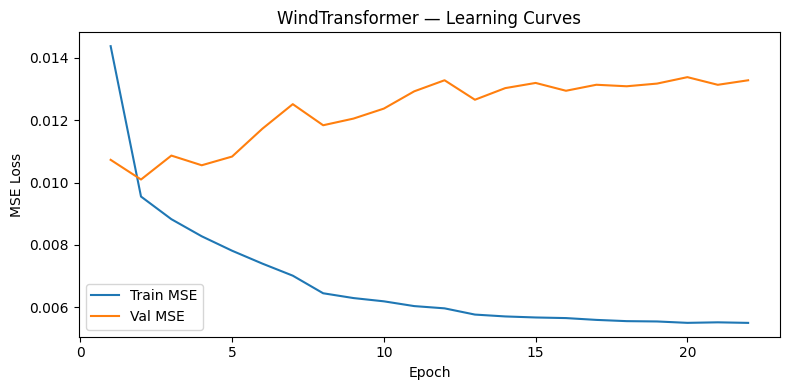

In [14]:
def plot_learning_curves(history: dict, model_name: str = 'model'):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs, history['train_loss'], label='Train MSE')
    plt.plot(epochs, history['val_loss'],   label='Val MSE')
    plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
    plt.title(f'{model_name} — Learning Curves')
    plt.legend(); plt.tight_layout(); plt.show()

plot_learning_curves(transformer_history, 'WindTransformer')

In [15]:
@torch.no_grad()
def predict(model, loader, device=DEVICE):
    """Run inference over a DataLoader; returns (y_pred, y_true, site_ids) as numpy arrays."""
    model.eval()
    preds, trues, sites = [], [], []
    for X_b, y_b, s_b in loader:
        out = model(X_b.to(device), s_b.to(device))
        preds.append(out.cpu().numpy())
        trues.append(y_b.numpy())
        sites.append(s_b.numpy())
    return (
        np.concatenate(preds).ravel(),
        np.concatenate(trues).ravel(),
        np.concatenate(sites).ravel(),
    )

# Generate test predictions
# y_true and site_ids come from the DataLoader → same site-grouped order as predictions
y_pred_transformer, y_true_transformer, site_ids_transformer = predict(transformer_model, test_loader)
transformer_site_names = np.array([site_mapping[s] for s in site_ids_transformer])

# Evaluate — both y_true and y_pred are in DataLoader order (aligned)
results_transformer = evaluate(y_true_transformer, y_pred_transformer,
                               transformer_site_names,
                               model_name='WindTransformer')

[WindTransformer]  Global — MAE=0.0769  RMSE=0.1073  nRMSE=0.1082  (n=26,390)
                                     MAE    RMSE   nRMSE     n
site                                                          
Northwester 2                     0.1028  0.1354  0.1379  2639
Norther Offshore WP               0.0792  0.1109  0.1143  2639
Northwind                         0.0752  0.1062  0.1076  2639
Thorntonbank - C-Power - Area NE  0.0742  0.1057  0.1079  2639
Mermaid Offshore WP               0.0776  0.1041  0.1057  2639
Rentel Offshore WP                0.0736  0.1023  0.1033  2639
Thorntonbank - C-Power - Area SW  0.0722  0.1016  0.1031  2639
Seastar Offshore WP               0.0729  0.1008  0.1021  2639
Nobelwind Offshore Windpark       0.0706  0.1008  0.1021  2639
Belwind Phase 1                   0.0708  0.1001  0.1042  2639


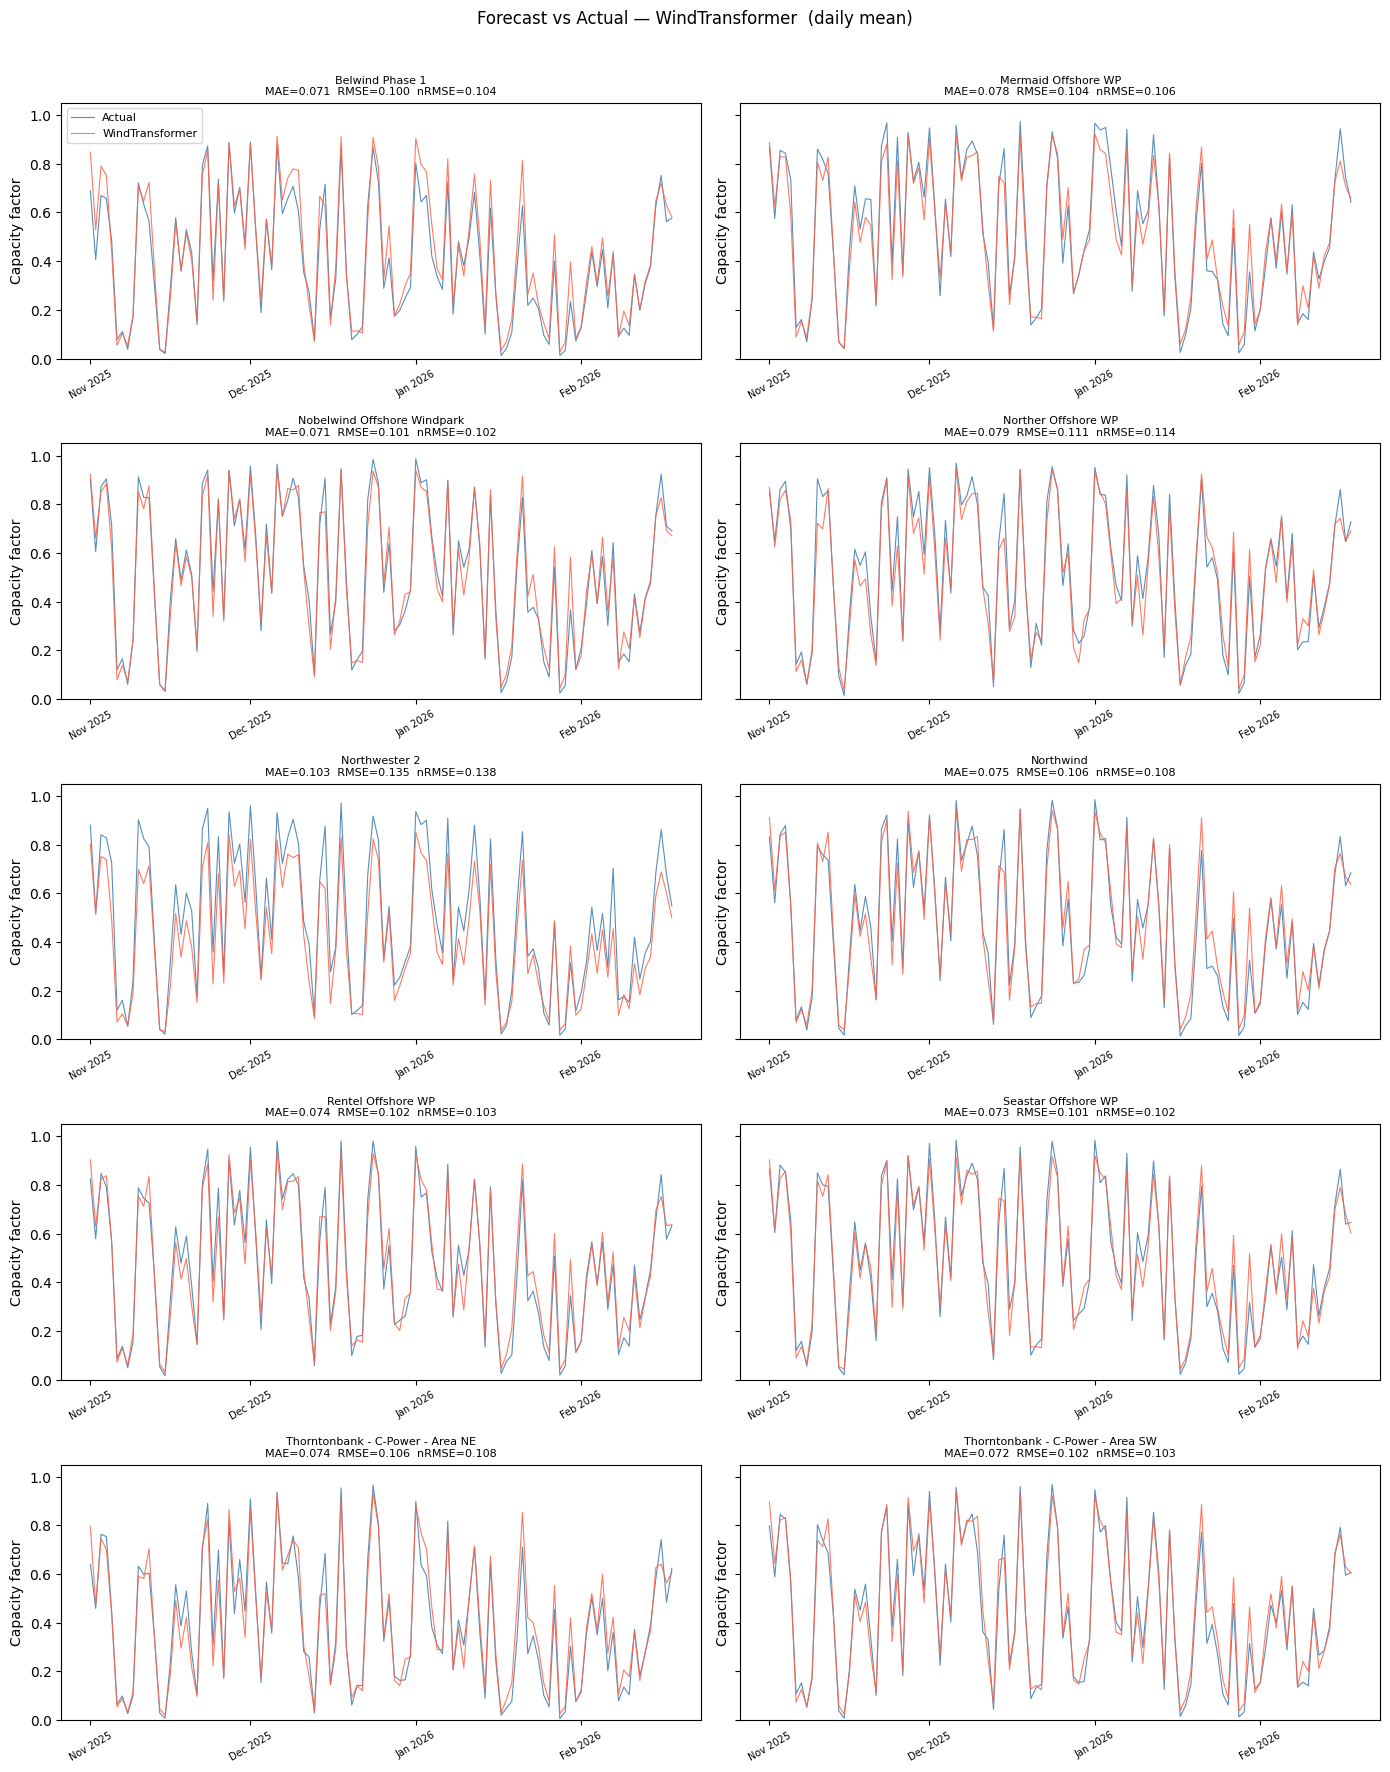

In [16]:
# Align delivery times with site-grouped sequence order (matches prediction order)
_times = []
for sid in np.sort(np.unique(meta_test['site_id'].values)):
    mask = meta_test['site_id'].values == sid
    _times.append(meta_test['delivery_time'].values[mask])
transformer_delivery_times = np.concatenate(_times)

plot_forecast(
    delivery_times = transformer_delivery_times,
    y_true         = y_true_transformer,
    y_pred         = y_pred_transformer,
    site_names     = transformer_site_names,
    model_name     = 'WindTransformer',
    resample       = 'D',
)

In [ ]:
from pathlib import Path

MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

save_path = MODELS_DIR / 'transformer_wind_rmse.pt'
torch.save({
    'model_state_dict': transformer_model.state_dict(),
    'model_cfg':        TRANSFORMER_CFG,
    'feature_names':    FEATURE_NAMES,
    'site_mapping':     site_mapping,
    'val_mse':          min(transformer_history['val_loss']),
}, save_path)

print(f'Transformer model saved → {save_path}')

Transformer model saved → models\transformer_wind.pt
